In [1]:
import pandas as pd
import numpy as np
import glob, os
import seaborn as sns

C:\Users\uttar\AppData\Local\Temp\ipykernel_6416\1380126047.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
buildings_mass_Gt = pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\DavidFrantzData\extracted_to_places\building_Gt_10km.tif.csv', encoding='latin-1',
            dtype = {'GEOID':str})

In [3]:
streets_mass_Gt = pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\DavidFrantzData\extracted_to_places\street_Gt_10km.tif.csv', encoding='latin-1',
            dtype = {'GEOID':str})

In [4]:
buildings_mass_Gt.isna().sum(), streets_mass_Gt.isna().sum()

(GEOID             0
 NAME              0
 NAMELSAD          0
 stocks_sum        0
 stocks_mean    1089
 stocks_std     1089
 dtype: int64,
 GEOID             0
 NAME              0
 NAMELSAD          0
 stocks_sum        0
 stocks_mean    1089
 stocks_std     1089
 dtype: int64)

In [5]:
df_population = pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\DavidFrantzData\forecasted_trend.csv', 
                            index_col  = 0, dtype = {'GEOID': str})



In [117]:
# df_population.columns, df_attributes.columns

In [60]:
df_attributes = pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\DavidFrantzData\df_attributes.csv', 
                            index_col  = 0, dtype = {'GEOID': str})

In [62]:
df_population = df_population.merge(df_attributes[['GEOID', 'city type']], on = 'GEOID')

In [63]:
buildings_mass_Gt['building_mass_t'] = 1000000000 *buildings_mass_Gt['stocks_sum']

In [501]:
building_with_pop = buildings_mass_Gt.merge(df_population[['GEOID', 'CensusPop_20', 'city type','ALAND',
                                       'State', 'ssp22020', 'ssp22030', 
                                       'ssp22040', 'ssp22050','ssp22060']])

In [502]:
building_with_pop['per_cap_mass'] = building_with_pop['building_mass_t'] / building_with_pop['CensusPop_20']

In [503]:
building_with_po = building_with_pop.dropna()

In [504]:
# building_with_po[['State', 'NAME','stocks_sum', 'stocks_mean', 'stocks_std', 'building_mass_t', 'CensusPop_20', 'label', 'per_cap_mass']].sort_values(by = 'per_cap_mass').tail(5000)

In [514]:
streets_mass_Gt['streets_mass_t'] = 1000000000 *streets_mass_Gt['stocks_sum']
stocks_with_pop = building_with_po.merge(streets_mass_Gt[['GEOID', 'streets_mass_t']], on = 'GEOID')

### Degree of urbanization

In [585]:
import numpy as np
import pandas as pd
import seaborn as sns
import math
import statsmodels.formula.api as sm
from statsmodels.stats.anova import anova_lm

def find_scale_parameters(df, infra_col, pop_col):
    df['log_pop_col'] = np.log(df[pop_col])
    df['log_infra_col'] = np.log(df[infra_col])
    
    # Check plot how the log-log plot looks?
    # ADD A QUESTION ASKING WHETHER A PLOT OR NOT???
    sns.regplot(x='log_pop_col', y='log_infra_col', data=df, 
                y_jitter=.03, ci =None, scatter_kws={"s": 1})
    x = df['log_pop_col']
    y = df['log_infra_col']

    #run anova model to find confidence intervals
    # Fit the regression model
    model = sm.ols("y ~ x", data={"y": y, "x": x}).fit()

    # Display regression summary
    # print(model.summary())
    print(model.params)
    # Calculate confidence intervals using ANOVA
    anova_result = anova_lm(model)
    conf_int = model.conf_int(alpha=0.05, cols=None)

    # Display ANOVA results and confidence intervals
    print("\nConfidence Intervals: 'log(a)' and 'b' values---")
    print(conf_int)
    intercepts = [conf_int.iloc[0][0], conf_int.iloc[0][1]]
    beta = [conf_int.iloc[1][0], conf_int.iloc[1][1]]
    model_params = model.params
    return intercepts, beta, model_params


In [598]:
stocks_with_pop = building_with_po.merge(streets_mass_Gt[['GEOID', 'streets_mass_t']], on = 'GEOID')
# stocks_with_pop = stocks_with_pop[stocks_with_pop['city type'] == 'rural']
# stocks_with_pop = stocks_with_pop[stocks_with_pop['city type'] == 'urban']
stocks_with_pop = stocks_with_pop[stocks_with_pop['city type'] == 'suburban']

stocks_with_pop.shape

(5999, 18)

Intercept    4.820289
x            0.980071
dtype: float64

Confidence Intervals: 'log(a)' and 'b' values---
                  0         1
Intercept  4.688035  4.952544
x          0.965054  0.995088


C:\Users\uttar\AppData\Local\Temp\ipykernel_6416\1427778092.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  size = condition.value_counts()[0]


,GEOID,NAME,city type,building_mass_t,streets_mass_t,additional_mass_building,added_mass_building,building_mass_reg,per_cap_mass,per_cap_mass_40,CensusPop_20,ssp22020,ssp22040
21513,4752006,Nashville-Davidson metropolitan government (ba...,suburban,1.552438e+08,4.330241e+07,-5.068467e+06,6.033040e+07,6.539887e+07,225.171433,183.344095,689447,6.932610e+05,8.190899e+05
291,1235000,Jacksonville,suburban,1.453446e+08,6.319483e+07,-4.149067e+06,8.535527e+07,8.950434e+07,153.056973,126.748479,949611,9.546111e+05,1.113982e+06
1518,1319000,Columbus,suburban,3.590035e+07,1.204923e+07,-2.363557e+06,1.774092e+07,2.010448e+07,173.497021,146.889099,206922,2.080961e+05,2.283137e+05
24388,5157000,Norfolk,suburban,3.900425e+07,1.243654e+07,-1.900305e+06,2.115978e+07,2.306009e+07,163.879951,140.630849,238005,2.394410e+05,2.638393e+05
18284,4123850,Eugene,suburban,1.605328e+07,5.373985e+06,-1.770311e+06,1.544752e+07,1.721783e+07,90.874127,69.433094,176654,1.776392e+05,2.057084e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21554,4748000,Memphis,suburban,1.389224e+08,3.565523e+07,2.725408e+07,8.741055e+07,6.015647e+07,219.430675,239.305059,633104,6.368416e+05,6.944129e+05
22010,4824000,El Paso,suburban,6.228455e+07,2.291358e+07,3.046501e+07,9.487531e+07,6.441030e+07,91.754825,119.160411,678815,6.827065e+05,7.783589e+05
22265,4805000,Austin,suburban,1.310448e+08,4.254348e+07,3.265201e+07,1.232872e+08,9.063523e+07,136.241793,134.030704,961855,9.675556e+05,1.221338e+06
16670,3918000,Columbus,suburban,1.420642e+08,3.713529e+07,3.978177e+07,1.252324e+08,8.545058e+07,156.847427,169.754538,905748,9.108558e+05,1.071229e+06


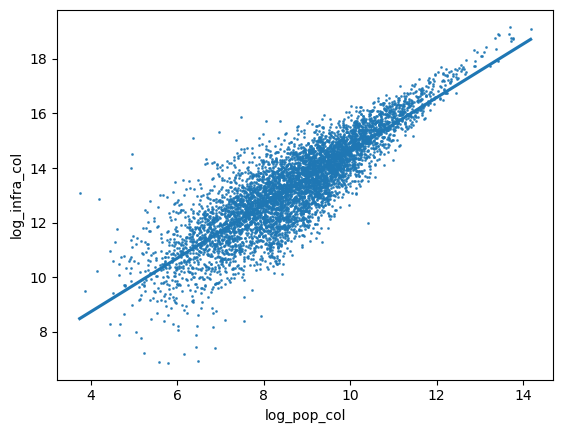

In [599]:
# intercepts, beta, model_params = find_scale_parameters(stocks_with_pop, infra_col= 'streets_mass_t', pop_col = 'CensusPop_20')

existing_stock_col = 'building_mass_t'

x = find_scale_parameters(stocks_with_pop, infra_col= existing_stock_col, pop_col = 'CensusPop_20')
stocks_with_pop['building_mass_reg'] = math.exp(x[2].Intercept)*stocks_with_pop.loc[:, 'CensusPop_20']**x[2].x

# Set the range for the uniform distribution
log_a_lower = x[0][0]
log_a_upper= x[0][1]

beta_lower = x[1][0]
beta_upper= x[1][1]

# Create a uniform distribution
log_a_uniform = np.random.uniform(low=log_a_lower, high=log_a_upper, size=100000)
beta_uniform = np.random.uniform(low=beta_lower, high=beta_upper, size=100000)

# CHECK THE NUMEBR OF TRUE AND FALSE VALUES 
# stocks_with_pop['label'].str.contains('depopulating').value_counts().iloc[0]
stocks_with_pop['added_mass_building'] = np.nan

# Define a condition
condition = stocks_with_pop['ssp22040'] < stocks_with_pop['CensusPop_20'] #stocks_with_pop['label'].str.contains('depopulating')

# Fill the column based on the condition
stocks_with_pop.loc[condition, 'added_mass_building'] = 0
# stocks_with_pop.loc[~condition, 'added_mass_building'] = (np.random.choice(a_uniform, 
#                                                                           size=11776) * stocks_with_pop.loc[~condition, 'CensusPop_20']**(np.random.choice(beta_uniform,
#                                                                           size=11776))) #- stocks_with_pop.loc[~condition, 'building_mass_t']
size = condition.value_counts()[0]
# Define a custom function to generate samples
def sample_function(p):
    return np.exp(np.random.choice(log_a_uniform,  size =1)) * (p ** np.random.choice(beta_uniform, size=1))
# Number of samples to take for each row
num_samples = 100

# Generate samples and calculate the mean for each row
stocks_with_pop.loc[~condition, 'added_mass_building'] = np.mean(np.array([np.random.choice(sample_function(p), size=num_samples) for p in stocks_with_pop.loc[~condition, 'ssp22040']]), axis=1)

stocks_with_pop['additional_mass_building'] = np.where(stocks_with_pop['added_mass_building'] == 0, 0, stocks_with_pop['added_mass_building'] - stocks_with_pop['building_mass_reg'])

stocks_with_pop['per_cap_mass_40'] = (stocks_with_pop[existing_stock_col] + stocks_with_pop['additional_mass_building'])/stocks_with_pop['ssp22040'] 

stocks_with_pop['per_cap_mass'] = stocks_with_pop[existing_stock_col] / stocks_with_pop['CensusPop_20']

stocks_with_pop[['GEOID', 'NAME', 'city type', 'building_mass_t', 'streets_mass_t','additional_mass_building', 'added_mass_building','building_mass_reg', 'per_cap_mass','per_cap_mass_40',
                 'CensusPop_20', 'ssp22020', 'ssp22040']].sort_values(by ='additional_mass_building')

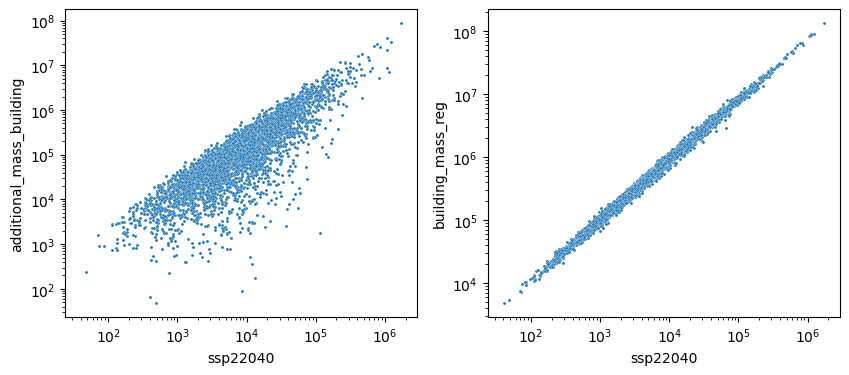

In [600]:
# sns.relplot(x='CensusPop_20', y='additional_mass_building', data=stocks_with_pop,)

import matplotlib.pyplot as plt
columns = ['additional_mass_building', 'building_mass_reg']
f, axes = plt.subplots(ncols = 2, figsize=(10, 4))
for ax, col in zip(axes, columns):
    ax.set(xscale="log", yscale="log")
    sns.scatterplot(ax=ax, data=stocks_with_pop, y=col, x ='ssp22040', s =5,) #  hue="label",)

In [473]:
stocks_with_pop[['streets_mass_t','additional_mass_building', 'added_mass_building','building_mass_reg', 'building_mass_t', 
                 'CensusPop_20', 'ssp22020', 'ssp22040']].sum()

streets_mass_t              4.559404e+09
additional_mass_building    1.759467e+09
added_mass_building         1.094816e+10
building_mass_reg           9.920719e+09
building_mass_t             1.380884e+10
CensusPop_20                1.008520e+08
ssp22020                    1.014553e+08
ssp22040                    1.170376e+08
dtype: float64

In [474]:
# sns.relplot(x='CensusPop_20', y='building_mass_t', data=stocks_with_pop, col = 'city type', s= 15)

C:\Users\uttar\AppData\Local\Temp\ipykernel_6416\2753916037.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  building_with_po['log_pop'] = np.log(building_with_po['CensusPop_20'])
C:\Users\uttar\AppData\Local\Temp\ipykernel_6416\2753916037.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  building_with_po['log_building_mass_t'] = np.log(building_with_po['building_mass_t'])


<Axes: xlabel='log_building_mass_t', ylabel='log_pop'>

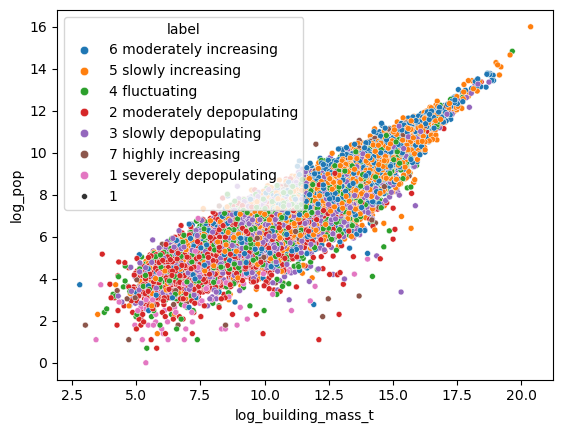

In [475]:
building_with_po['log_pop'] = np.log(building_with_po['CensusPop_20'])
building_with_po['log_building_mass_t'] = np.log(building_with_po['building_mass_t'])

import seaborn as sns
sns.scatterplot(building_with_po, x='log_building_mass_t', y='log_pop', hue="label", size =1)

C:\Users\uttar\AppData\Local\Temp\ipykernel_6416\282901094.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  building_with_po['log_per_cap_mass'] = np.log2(building_with_po['per_cap_mass'])
C:\Users\uttar\AppData\Local\Temp\ipykernel_6416\282901094.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  building_with_po['per_cap_mass_40'] = building_with_po['building_mass_t'] / building_with_po['ssp22040']
C:\Users\uttar\AppData\Local\Temp\ipykernel_6416\282901094.py:6: SettingWithCopyWarning: 
A value is try

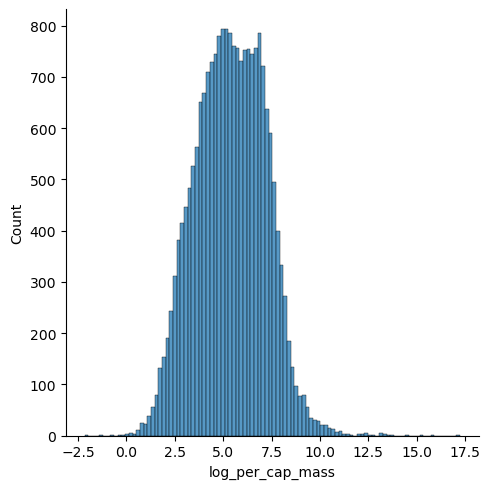

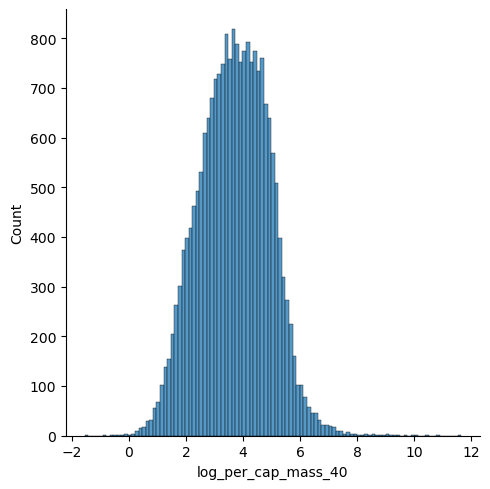

In [45]:
building_with_po.columns
building_with_po['log_per_cap_mass'] = np.log2(building_with_po['per_cap_mass'])

# considering everything remains same except population
building_with_po['per_cap_mass_40'] = building_with_po['building_mass_t'] / building_with_po['ssp22040']
building_with_po['log_per_cap_mass_40'] = np.log(building_with_po['per_cap_mass_40'])

import seaborn as sns
sns.displot(data=building_with_po, x='log_per_cap_mass')
sns.displot(data=building_with_po, x='log_per_cap_mass_40')

<Axes: xlabel='log_per_cap_mass', ylabel='Count'>

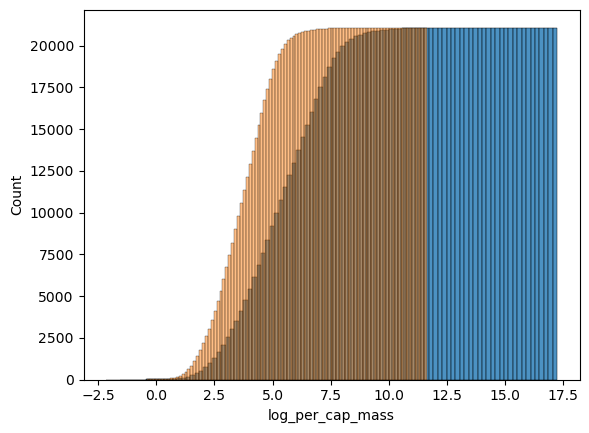

In [46]:
# sns.ecdfplot(data=building_with_po, x='log_per_cap_mass')
# sns.ecdfplot(data=building_with_po, x='log_per_cap_mass_40')

sns.histplot(data=building_with_po, x='log_per_cap_mass', cumulative=True, alpha=0.8)
sns.histplot(data=building_with_po, x='log_per_cap_mass_40', cumulative=True, alpha=0.5)

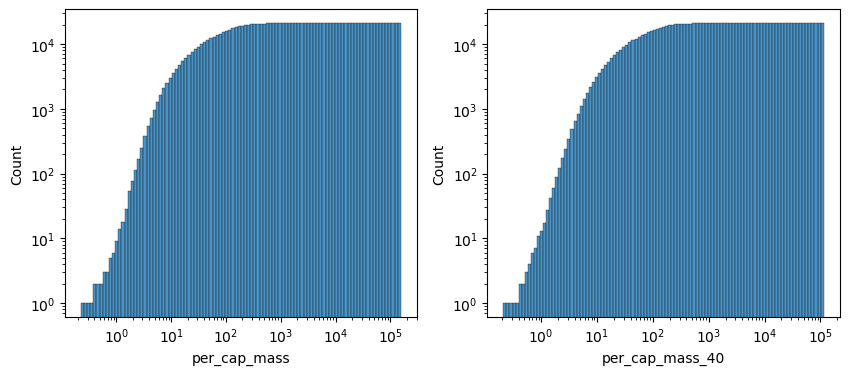

In [47]:
import matplotlib.pyplot as plt
columns = ['per_cap_mass', 'per_cap_mass_40']
f, axes = plt.subplots(ncols = 2, figsize=(10, 4))
for ax, col in zip(axes, columns):
    ax.set(xscale="log", yscale="log")
    sns.histplot(ax=ax, data=building_with_po, x=col, cumulative=True, alpha=0.8)
    # sns.scatterplot(ax=ax, data = building_with_po, x=col, y='CensusPop_20', size =0.5)